In [91]:
%load_ext memory_profiler

In [115]:
# %load_ext autotime

##### v1, 129 seconds to completion

In [116]:
%%memit
import numpy as np

# Grid parameters
nx, ny, nz = 100, 100, 100  # Number of grid points
dx = dy = dz = 1.0          # Grid spacing
dt = 1                    # Time step
alpha = 0.15             # Thermal diffusivity
nt = 1000                   # Number of time steps

def second_derivative_z(u_z):
    """
    Compute the second derivative along the z-axis using central differences.
    Assumes Neumann boundary conditions (zero derivative at boundaries).
    """
    d2u_dz2 = np.zeros_like(u_z)
    d2u_dz2[1:-1] = (u_z[2:] - 2 * u_z[1:-1] + u_z[:-2]) / dz**2
    return d2u_dz2

def main():
    # Initialize the temperature field with initial conditions
    u = np.zeros((nx, ny, nz))
    u[nx//2,ny//2, 0] = 1.0  # place heat source here 

    for _ in range(nt):
        # Compute second derivative along the z-axis using apply_along_axis
        # d2u_dz2 = np.apply_along_axis(second_derivative_z, axis=2, arr=u)
        # Compute second derivative along the x-axis
        d2u_dz2 = np.zeros_like(u)
        # d2u_dx2[1:-1, :, :] = 0
        d2u_dz2[:, :, 1:-1] = (u[:, :, 2:] - 2 * u[:, :, 1:-1] + u[:, :, :-2]) / dz**2
        
        # Compute second derivative along the x-axis
        d2u_dx2 = np.zeros_like(u)
        # d2u_dx2[1:-1, :, :] = 0
        d2u_dx2[1:-1, :, :] = (u[2:, :, :] - 2 * u[1:-1, :, :] + u[:-2, :, :]) / dx**2

        # Compute second derivative along the y-axis
        d2u_dy2 = np.zeros_like(u)
        # d2u_dy2[:, 1:-1, :] = 0

        d2u_dy2[:, 1:-1, :] = (u[:, 2:, :] - 2 * u[:, 1:-1, :] + u[:, :-2, :]) / dy**2

        # Update the temperature field
        u += alpha * dt * (d2u_dx2 + d2u_dy2 + d2u_dz2)

    # Optionally, return or save the final temperature field
    return u

if __name__ == "__main__":
    final_temperature = main()


peak memory: 423.68 MiB, increment: 45.80 MiB


##### vectorized using np.roll 122 seconds to completion

In [117]:
# %%memit
# %%time

# import numpy as np

# Grid parameters
nx, ny, nz = 100, 100, 100  # Number of grid points
dx = dy = dz = 1.0          # Grid spacing
dt = 1                      # Time step
alpha = 0.15                # Thermal diffusivity
nt = 1000                    # Number of time steps

def main():
    # Initialize the temperature field with initial conditions
    u = np.zeros((nx, ny, nz))
    u[nx // 2, ny // 2, 0] = 1.0  # place heat source here 

    for _ in range(nt):
        # Compute second derivative along the z-axis
        d2u_dz2 = (np.roll(u, -1, axis=2) - 2 * u + np.roll(u, 1, axis=2)) / dz**2
        d2u_dz2[:, :, 0] = (u[:, :, 1] - u[:, :, 0]) / dz**2  # Neumann BC at z=0
        d2u_dz2[:, :, -1] = (u[:, :, -2] - u[:, :, -1]) / dz**2  # Neumann BC at z=nz-1

        # Compute second derivative along the x-axis
        d2u_dx2 = (np.roll(u, -1, axis=0) - 2 * u + np.roll(u, 1, axis=0)) / dx**2
        d2u_dx2[0, :, :] = (u[1, :, :] - u[0, :, :]) / dx**2  # Neumann BC at x=0
        d2u_dx2[-1, :, :] = (u[-2, :, :] - u[-1, :, :]) / dx**2  # Neumann BC at x=nx-1

        # Compute second derivative along the y-axis
        d2u_dy2 = (np.roll(u, -1, axis=1) - 2 * u + np.roll(u, 1, axis=1)) / dy**2
        d2u_dy2[:, 0, :] = (u[:, 1, :] - u[:, 0, :]) / dy**2  # Neumann BC at y=0
        d2u_dy2[:, -1, :] = (u[:, -2, :] - u[:, -1, :]) / dy**2  # Neumann BC at y=ny-1

        # Update the temperature field
        u += alpha * dt * (d2u_dx2 + d2u_dy2 + d2u_dz2)

    # Optionally, return or save the final temperature field
    return u

if __name__ == "__main__":
    final_temperature = main()


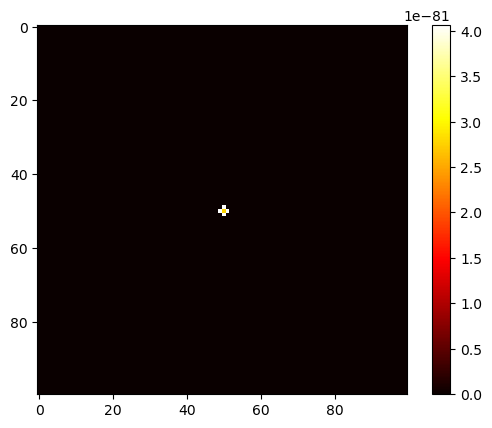

In [98]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# Plot a slice at z = nz // 2
plt.imshow(final_temperature[:, :, 99], cmap='hot')#, vmin = 0, vmax = 1)
plt.colorbar()
plt.show()

In [90]:
final_temperature[nx//2,ny//2,0]


0.0007617260670990519

#### Using CUPY 4 seconds to completion

In [118]:
# %%memit
# %%time
import cupy as cp

# Grid parameters
nx, ny, nz = 100, 100, 100  # Number of grid points
dx = dy = dz = 1.0          # Grid spacing
dt = 1                      # Time step
alpha = 0.15                # Thermal diffusivity
nt = 1000                    # Number of time steps

def main():
    # Initialize the temperature field with initial conditions (using CuPy)
    u = cp.zeros((nx, ny, nz))
    u[nx // 2, ny // 2, 0] = 1.0  # place heat source here 

    for _ in range(nt):
        # Compute second derivative along the z-axis
        d2u_dz2 = (cp.roll(u, -1, axis=2) - 2 * u + cp.roll(u, 1, axis=2)) / dz**2
        d2u_dz2[:, :, 0] = (u[:, :, 1] - u[:, :, 0]) / dz**2  # Neumann BC at z=0
        d2u_dz2[:, :, -1] = (u[:, :, -2] - u[:, :, -1]) / dz**2  # Neumann BC at z=nz-1

        # Compute second derivative along the x-axis
        d2u_dx2 = (cp.roll(u, -1, axis=0) - 2 * u + cp.roll(u, 1, axis=0)) / dx**2
        d2u_dx2[0, :, :] = (u[1, :, :] - u[0, :, :]) / dx**2  # Neumann BC at x=0
        d2u_dx2[-1, :, :] = (u[-2, :, :] - u[-1, :, :]) / dx**2  # Neumann BC at x=nx-1

        # Compute second derivative along the y-axis
        d2u_dy2 = (cp.roll(u, -1, axis=1) - 2 * u + cp.roll(u, 1, axis=1)) / dy**2
        d2u_dy2[:, 0, :] = (u[:, 1, :] - u[:, 0, :]) / dy**2  # Neumann BC at y=0
        d2u_dy2[:, -1, :] = (u[:, -2, :] - u[:, -1, :]) / dy**2  # Neumann BC at y=ny-1

        # Update the temperature field
        u += alpha * dt * (d2u_dx2 + d2u_dy2 + d2u_dz2)

    # Optionally, return or save the final temperature field
    return u

if __name__ == "__main__":
    final_temperature = main()
    # If you need to bring the result back to the CPU:
    final_temperature_cpu = cp.asnumpy(final_temperature)


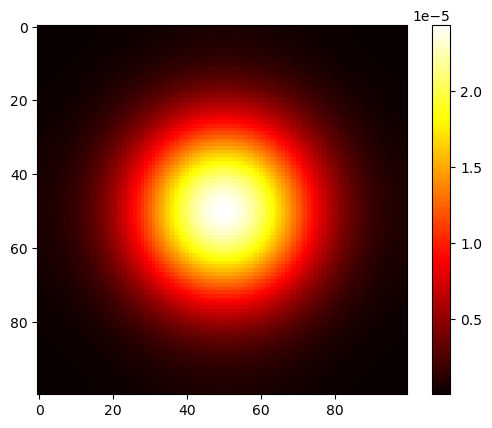

In [114]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# Plot a slice at z = nz // 2
plt.imshow(final_temperature_cpu[:, :, 0], cmap='hot')#, vmin = 0, vmax = 1)
plt.colorbar()
plt.show()

In [4]:
import numpy as np

# Grid parameters
nr, ntheta, nz = 100, 100, 100  # Number of grid points in r, theta, z
r_max = 10.0                    # Maximum radius
z_max = 10.0                    # Maximum height

dr = r_max / nr                 # Radial grid spacing
dtheta = 2 * np.pi / ntheta     # Angular grid spacing
dz = z_max / nz                 # Axial grid spacing

dt = 0.01                       # Time step
alpha = 0.01                    # Thermal diffusivity
nt = 10                       # Number of time steps

# Create radial and angular coordinate arrays
r = np.linspace(0 + dr/2, r_max - dr/2, nr)  # Avoid r=0 to prevent division by zero
theta = np.linspace(0, 2 * np.pi, ntheta, endpoint=False)
z = np.linspace(0, z_max, nz)

def second_derivative_z(u_z):
    """
    Compute the second derivative along the z-axis using central differences.
    Assumes Neumann boundary conditions (zero gradient at boundaries).
    """
    d2u_dz2 = np.zeros_like(u_z)
    d2u_dz2[1:-1] = (u_z[2:] - 2 * u_z[1:-1] + u_z[:-2]) / dz**2
    # Neumann boundary conditions
    d2u_dz2[0] = (u_z[1] - u_z[0]) / dz**2
    d2u_dz2[-1] = (u_z[-2] - u_z[-1]) / dz**2
    return d2u_dz2

def main():
    # Initialize the temperature field
    u = np.zeros((nr, ntheta, nz))
    T0 = 100.0  # Initial temperature at z=0
    u[:, :, 0] = T0  # Uniform temperature at z=0 across r and theta

    for _ in range(nt):
        # Compute second derivative along the z-axis using apply_along_axis
        d2u_dz2 = np.apply_along_axis(second_derivative_z, axis=2, arr=u)

        # Compute second derivative along the r-axis
        d2u_dr2 = np.zeros_like(u)
        for i in range(1, nr - 1):
            u_plus = u[i + 1, :, :]
            u_minus = u[i - 1, :, :]
            u_i = u[i, :, :]
            d2u_dr2[i, :, :] = ((u_plus - 2 * u_i + u_minus) / dr**2 +
                                (u_plus - u_minus) / (2 * dr * r[i]))
        # Boundary at r=0 (special case)
        i = 0
        u_plus = u[i + 1, :, :]
        u_i = u[i, :, :]
        d2u_dr2[i, :, :] = (2 * (u_plus - u_i) / dr**2)

        # Boundary at r=r_max (Neumann boundary condition)
        i = nr - 1
        u_minus = u[i - 1, :, :]
        u_i = u[i, :, :]
        d2u_dr2[i, :, :] = (2 * (u_minus - u_i) / dr**2)

        # Compute second derivative along the theta-axis
        d2u_dtheta2 = np.zeros_like(u)
        r_squared = r[:, None] ** 2  # Shape: (nr, 1)
        for j in range(ntheta):
            jp = (j + 1) % ntheta  # Periodic boundary condition
            jm = (j - 1) % ntheta
            u_jp = u[:, jp, :]
            u_jm = u[:, jm, :]
            u_j = u[:, j, :]
            numerator = (u_jp - 2 * u_j + u_jm) / dtheta**2  # Shape: (nr, nz)
            d2u_dtheta2[:, j, :] = numerator / r_squared  # Broadcast over nz

        # Update the temperature field
        u += alpha * dt * (d2u_dr2 + d2u_dtheta2 + d2u_dz2)

    # Optionally, return or save the final temperature field
    return u

if __name__ == "__main__":
    final_temperature = main()


In [5]:
import matplotlib.pyplot as plt

z_index = 99  # Middle of the z-axis
plt.imshow(u[:, :, z_index], extent=(0, r_max, 0, 2 * np.pi), aspect='auto', cmap='hot')
plt.colorbar(label='Temperature')
plt.xlabel('Radius (r)')
plt.ylabel('Angle (θ)')
plt.title(f'Temperature Distribution at z={z[z_index]:.2f}')
plt.show()

NameError: name 'u' is not defined

In [3]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [4]:
%%memit
import cupy as cp

# Grid parameters
nr, ntheta, nz = 100, 100, 100  # Number of grid points in r, theta, z
r_max = 10.0                    # Maximum radius
z_max = 10.0                    # Maximum height

dr = r_max / nr                 # Radial grid spacing
dtheta = 2 * cp.pi / ntheta     # Angular grid spacing
dz = z_max / nz                 # Axial grid spacing

dt = 0.01                       # Time step
alpha = 0.01                    # Thermal diffusivity
nt = 100                        # Number of time steps

# Create radial and angular coordinate arrays
r = cp.linspace(0 + dr/2, r_max - dr/2, nr)  # Avoid r=0 to prevent division by zero
theta = cp.linspace(0, 2 * cp.pi, ntheta, endpoint=False)
z = cp.linspace(0, z_max, nz)

def second_derivative_z(u_z):
    """
    Compute the second derivative along the z-axis using central differences.
    Assumes Neumann boundary conditions (zero gradient at boundaries).
    """
    d2u_dz2 = cp.zeros_like(u_z)
    d2u_dz2[1:-1] = (u_z[2:] - 2 * u_z[1:-1] + u_z[:-2]) / dz**2
    # Neumann boundary conditions
    d2u_dz2[0] = (u_z[1] - u_z[0]) / dz**2
    d2u_dz2[-1] = (u_z[-2] - u_z[-1]) / dz**2
    return d2u_dz2

def main():
    # Initialize the temperature field
    u = cp.zeros((nr, ntheta, nz))
    T0 = 100.0  # Initial temperature at z=0
    u[:, :, 0] = T0  # Uniform temperature at z=0 across r and theta

    r_squared = r[:, cp.newaxis] ** 2  # Shape: (nr, 1)

    for _ in range(nt):
        # Compute second derivative along the z-axis using apply_along_axis
        d2u_dz2 = cp.apply_along_axis(second_derivative_z, axis=2, arr=u)

        # Compute second derivative along the r-axis
        d2u_dr2 = cp.zeros_like(u)
        u_plus = cp.roll(u, -1, axis=0)
        u_minus = cp.roll(u, 1, axis=0)
        u_i = u

        # Interior points
        d2u_dr2[1:-1, :, :] = ((u_plus[1:-1] - 2 * u_i[1:-1] + u_minus[1:-1]) / dr**2 +
                               (u_plus[1:-1] - u_minus[1:-1]) / (2 * dr * r[1:-1, cp.newaxis, cp.newaxis]))
        # Boundary at r=0
        d2u_dr2[0, :, :] = (2 * (u[1, :, :] - u[0, :, :]) / dr**2)
        # Boundary at r=r_max
        d2u_dr2[-1, :, :] = (2 * (u[-2, :, :] - u[-1, :, :]) / dr**2)

        # Compute second derivative along the theta-axis
        d2u_dtheta2 = cp.zeros_like(u)
        u_jp = cp.roll(u, -1, axis=1)
        u_jm = cp.roll(u, 1, axis=1)
        numerator = (u_jp - 2 * u + u_jm) / dtheta**2  # Shape: (nr, ntheta, nz)
        d2u_dtheta2 = numerator / r_squared[:, :, cp.newaxis]  # Broadcast over nz

        # Update the temperature field
        u += alpha * dt * (d2u_dr2 + d2u_dtheta2 + d2u_dz2)

    # Optionally, return or save the final temperature field
    return u

if __name__ == "__main__":
    final_temperature = main()

    # Transfer data back to CPU for further processing or visualization
    final_temperature_cpu = cp.asnumpy(final_temperature)


KeyboardInterrupt: 

In [47]:
import numpy as np

# Physical constants and parameters
R_moon = 1737.4e3  # Radius of the Moon in meters
alpha = 1e-6       # Thermal diffusivity in m^2/s (typical for rock)
T0 = 300.0         # Maximum initial temperature in Kelvin

# Grid parameters
nr = 50           # Number of radial grid points
ntheta = 50       # Number of polar angle grid points (θ from 0 to π/2)
nphi = 100        # Number of azimuthal angle grid points (φ from 0 to 2π)
nt = 1000         # Number of time steps
dt = 10.0         # Time step in seconds

# Spatial discretization
r = np.linspace(0, R_moon, nr)
theta = np.linspace(0, np.pi / 2, ntheta)
phi = np.linspace(0, 2 * np.pi, nphi, endpoint=False)

dr = r[1] - r[0]
dtheta = theta[1] - theta[0]
dphi = phi[1] - phi[0]

# Create 3D mesh grids
R, Theta, Phi = np.meshgrid(r, theta, phi, indexing='ij')

# Initial temperature distribution based on incident angle
T = np.zeros((nr, ntheta, nphi))
T[:, :, :] = T0 * np.cos(Theta)

def heat_diffusion(T, alpha, dr, dtheta, dphi, dt, r, theta):
    """
    Perform one time step of the heat diffusion equation in spherical coordinates.
    """
    T_new = np.copy(T)
    
    # Precompute sines and cosines
    sin_theta = np.sin(theta)
    sin_theta[sin_theta == 0] = 1e-10  # Avoid division by zero
    cos_theta = np.cos(theta)
    
    # Compute derivatives
    for i in range(1, nr - 1):
        for j in range(1, ntheta - 1):
            for k in range(nphi):
                # Radial derivatives
                dT_dr = (T[i + 1, j, k] - T[i - 1, j, k]) / (2 * dr)
                d2T_dr2 = (T[i + 1, j, k] - 2 * T[i, j, k] + T[i - 1, j, k]) / dr**2
                
                # Theta derivatives
                dT_dtheta = (T[i, j + 1, k] - T[i, j - 1, k]) / (2 * dtheta)
                d2T_dtheta2 = (T[i, j + 1, k] - 2 * T[i, j, k] + T[i, j - 1, k]) / dtheta**2
                
                # Phi derivatives (periodic boundary conditions)
                k_plus = (k + 1) % nphi
                k_minus = (k - 1) % nphi
                d2T_dphi2 = (T[i, j, k_plus] - 2 * T[i, j, k] + T[i, j, k_minus]) / dphi**2
                
                # Heat equation in spherical coordinates
                term_r = (1 / r[i]**2) * (r[i]**2 * d2T_dr2 + 2 * r[i] * dT_dr)
                term_theta = (1 / (r[i]**2 * sin_theta[j])) * (sin_theta[j] * d2T_dtheta2 + cos_theta[j] * dT_dtheta)
                term_phi = d2T_dphi2 / (r[i]**2 * sin_theta[j]**2)
                
                T_new[i, j, k] = T[i, j, k] + alpha * dt * (term_r + term_theta + term_phi)
    
    # Boundary conditions
    # At r = 0 (center), assume symmetry (no flux across center)
    T_new[0, :, :] = T_new[1, :, :]
    # At r = R_moon, insulated boundary (Neumann BC)
    T_new[-1, :, :] = T_new[-2, :, :]
    # At θ = 0 and θ = π/2, symmetry boundary conditions
    T_new[:, 0, :] = T_new[:, 1, :]
    T_new[:, -1, :] = T_new[:, -2, :]
    
    return T_new

def main():
    global T
    for n in range(nt):
        T = heat_diffusion(T, alpha, dr, dtheta, dphi, dt, r, theta)
        # Optional: Add code to monitor progress or visualize intermediate results
    return T

if __name__ == "__main__":
    final_temperature = main()


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Extract a radial slice at θ = π/4 and φ = 0
theta_index = ntheta // 2
phi_index = 0
temperature_slice = final_temperature[:, theta_index, phi_index]

plt.plot(r, temperature_slice)
plt.xlabel('Radius (m)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Profile along Radius at θ = π/4, φ = 0')
plt.show()

In [49]:
import numpy as np

# Physical constants and parameters
R_moon = 1737.4e3   # Radius of the Moon in meters
alpha = 1e-6        # Thermal diffusivity in m^2/s (typical for lunar rock)
T0 = 300.0          # Maximum initial temperature in Kelvin

# Grid parameters
nr = 50             # Number of radial grid points
ntheta = 50         # Number of polar angle grid points (θ from 0 to π/2)
nphi = 100          # Number of azimuthal angle grid points (φ from 0 to 2π)
nz = 100            # Number of depth grid points
nt = 1000           # Number of time steps
dt = 10.0           # Time step in seconds

# Spatial discretization
r = np.linspace(0, R_moon, nr)
theta = np.linspace(0, np.pi / 2, ntheta)
phi = np.linspace(0, 2 * np.pi, nphi, endpoint=False)
z = np.linspace(0, 1000, nz)  # Depth from the surface into the moon (in meters)

dz = z[1] - z[0]

# Create 4D mesh grids
R, Theta, Phi, Z = np.meshgrid(r, theta, phi, z, indexing='ij')

# Initial temperature distribution based on incident angle, uniform along depth
T = T0 * np.cos(Theta)[..., np.newaxis] * np.ones(nz)

def heat_diffusion_depth(T, alpha, dz, dt):
    """
    Perform one time step of the heat diffusion equation along the depth axis.
    """
    # Compute second derivative along the depth axis using central differences
    d2T_dz2 = np.zeros_like(T)
    d2T_dz2[..., 1:-1] = (T[..., 2:] - 2 * T[..., 1:-1] + T[..., :-2]) / dz**2

    # Neumann boundary conditions at the surface (z=0) and bottom (z=depth)
    # Surface boundary (z=0): assume constant temperature (due to incident radiation)
    d2T_dz2[..., 0] = 0  # No change at the surface
    # Bottom boundary (z=max): insulated boundary (zero gradient)
    d2T_dz2[..., -1] = (T[..., -2] - T[..., -1]) / dz**2

    # Update temperature field
    T_new = T + alpha * dt * d2T_dz2

    return T_new

def main():
    global T
    for n in range(nt):
        T = heat_diffusion_depth(T, alpha, dz, dt)
        # Optional: Monitor progress or visualize intermediate results
    return T

if __name__ == "__main__":
    final_temperature = main()


MemoryError: Unable to allocate 18.3 GiB for an array with shape (50, 50, 100, 100, 98) and data type float64

In [ ]:
import matplotlib.pyplot as plt

# Example: Temperature profile along depth at a specific location
r_index = nr // 2      # Midpoint in radial direction
theta_index = ntheta // 4  # Some angle
phi_index = nphi // 2  # Midpoint in azimuthal direction

depth_profile = final_temperature[r_index, theta_index, phi_index, :]

plt.figure(figsize=(8, 6))
plt.plot(z, depth_profile)
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Profile Along Depth')
plt.gca().invert_xaxis()  # Depth increases into the moon
plt.show()

In [48]:
import cupy as cp

# Physical constants and parameters
R_moon = 1737.4e3   # Radius of the Moon in meters
alpha = 1e-6        # Thermal diffusivity in m^2/s (typical for lunar rock)
T0 = 300.0          # Maximum initial temperature in Kelvin

# Grid parameters
nr = 50             # Number of radial grid points
ntheta = 50         # Number of polar angle grid points
nphi = 100          # Number of azimuthal angle grid points
nz = 100            # Number of depth grid points
nt = 1000           # Number of time steps
dt = 10.0           # Time step in seconds

# Spatial discretization
r = cp.linspace(0, R_moon, nr)
theta = cp.linspace(0, cp.pi / 2, ntheta)
phi = cp.linspace(0, 2 * cp.pi, nphi, endpoint=False)
z = cp.linspace(0, 1000, nz)  # Depth from the surface into the moon (in meters)

dz = z[1] - z[0]

# Create 4D mesh grids
R, Theta, Phi, Z = cp.meshgrid(r, theta, phi, z, indexing='ij')

# Initial temperature distribution based on incident angle, uniform along depth
T = T0 * cp.cos(Theta)[..., cp.newaxis] * cp.ones(nz)

def heat_diffusion_depth(T, alpha, dz, dt):
    """
    Perform one time step of the heat diffusion equation along the depth axis.
    """
    # Compute second derivative along the depth axis using central differences
    d2T_dz2 = cp.zeros_like(T)
    d2T_dz2[..., 1:-1] = (T[..., 2:] - 2 * T[..., 1:-1] + T[..., :-2]) / dz**2

    # Neumann boundary conditions at the surface (z=0) and bottom (z=depth)
    # Surface boundary (z=0): assume constant temperature (due to incident radiation)
    d2T_dz2[..., 0] = 0  # No change at the surface
    # Bottom boundary (z=max): insulated boundary (zero gradient)
    d2T_dz2[..., -1] = (T[..., -2] - T[..., -1]) / dz**2

    # Update temperature field
    T_new = T + alpha * dt * d2T_dz2

    return T_new

def main():
    global T
    for n in range(nt):
        T = heat_diffusion_depth(T, alpha, dz, dt)
        # Optional: Monitor progress or visualize intermediate results
    return T

if __name__ == "__main__":
    final_temperature = main()

    # Transfer data back to CPU for further processing or visualization
    final_temperature_cpu = cp.asnumpy(final_temperature)


C:\Users\seane\anaconda3\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


RuntimeError: CuPy failed to load nvrtc64_120_0.dll: FileNotFoundError: Could not find module 'nvrtc64_120_0.dll' (or one of its dependencies). Try using the full path with constructor syntax.